In [2]:
using HDF5, LaTeXStrings, Plots.PlotMeasures, Plots
include("params.jl");

# Compute inspiral

In [3]:
@time iChimera.compute_inspiral(emri; JIT = true);

JIT compilation run complete.
  4.579843 seconds (12.35 M allocations: 564.889 MiB, 6.31% gc time, 98.45% compilation time: 96% of which was recompilation)


In [4]:
@time iChimera.compute_inspiral(emri);

File created: ./Results/Data/EMRI_sol_a_0.9_p_7.0_e_0.1_θmin_0.571_q_1.0e-5_psi0_0.1_chi0_0.2_phi0_0.3_BL_time_lmax_mass_fluxes_3_lmax_current_fluxes_2_cartesian.h5
  1.118095 seconds (377.31 k allocations: 22.511 MiB, 0.38% compilation time)


# Plot constants of motion

In [ ]:
t, r, θ, ϕ = iChimera.load_trajectory(emri);
t = t * MtoSecs;

# load fluxes
t_Fluxes, EE, LL, QQ, CC, pArray, ecc, θminArray = iChimera.load_constants_of_motion(emri);
t_Fluxes, Edot, Ldot, Qdot, Cdot = iChimera.load_fluxes(emri);

t_Fluxes = t_Fluxes * MtoSecs;

# compute iota
ι = @. acos(LL / sqrt(LL^2 + CC));

In [9]:
col = :blue
ls = :solid
lw = 2.0

wave_im_ratio = 5   # width / height
wave_height = 300; wave_width = wave_height * wave_im_ratio
xtickfontsize=10; ytickfontsize=10; guidefontsize=15;
# margins
left_margin = 8mm; right_margin=8mm; top_margin=8mm; bottom_margin=8mm;

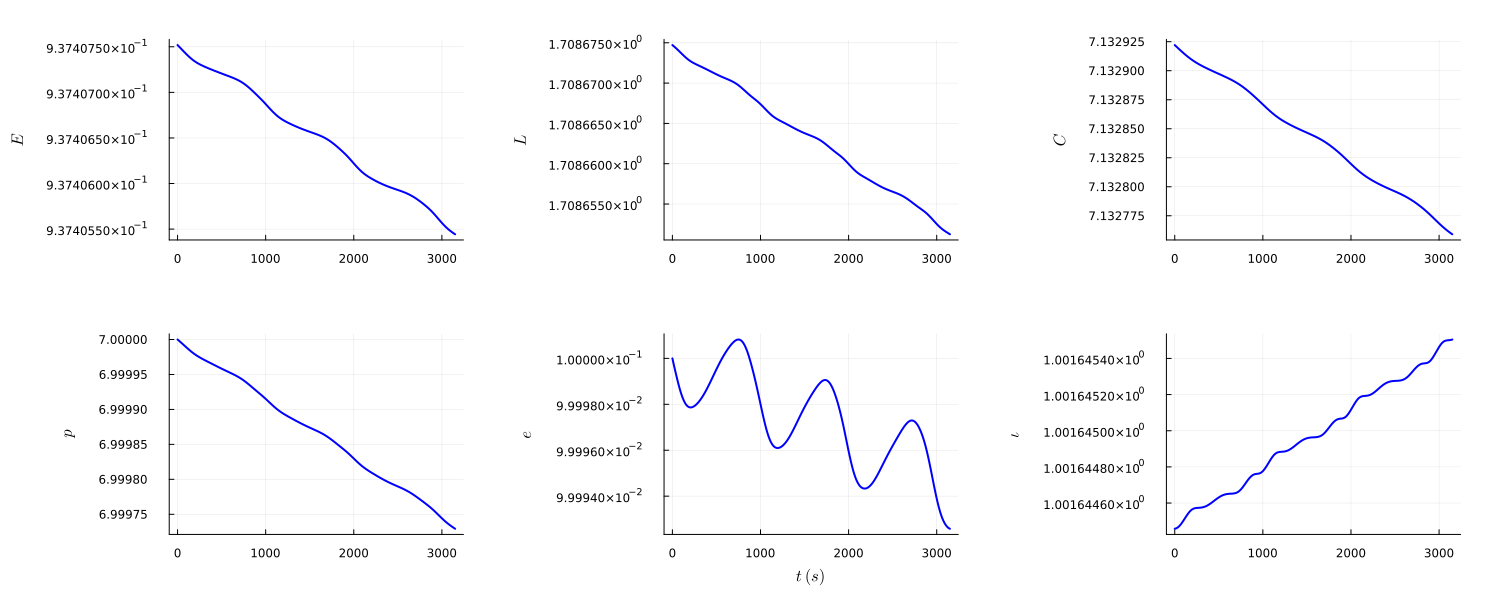

In [10]:
gr()
# plot BL results
plotE = Plots.plot(t_Fluxes, EE, ylabel=L"E", legend=:false,
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)

plotL = Plots.plot(t_Fluxes, LL, ylabel=L"L", legend=:false,
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)

plotC = Plots.plot(t_Fluxes, CC, ylabel=L"C", legend=:false,
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)

plotP = Plots.plot(t_Fluxes, pArray, ylabel=L"p", legend=:false, 
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)

plotEcc = Plots.plot(t_Fluxes, ecc, ylabel=L"e", xlabel=L"t\ (s)", legend=:false,
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)

plotι = Plots.plot(t_Fluxes, ι, ylabel=L"\iota", legend=:false,
    color=col, linestyle=ls, linewidth=lw,
    left_margin =  left_margin,
    right_margin =  right_margin,
    top_margin =  top_margin,
    bottom_margin =  bottom_margin)


orbitalParamsPlot=plot(plotE, plotL, plotC, plotP, plotEcc, plotι, layout = @layout([[A B C]; [D E F]]), 
size=(1500, 600), dpi=100)
display("image/png", orbitalParamsPlot)

# Waveform computation

In [11]:
@time iChimera.compute_waveform(emri);

File created: ./Results/Data/Waveform_a_0.9_p_7.0_e_0.1_θmin_0.571_q_1.0e-5_psi0_0.1_chi0_0.2_phi0_0.3_obsDist_1.0_ThetaS_10.0_PhiS_5.0_ThetaK_6.0_PhiK_8.0_BL_time_lmax_mass_fluxes_3_lmax_current_fluxes_2_lmax_mass_waveform_4_lmax_current_waveform_3_cartesian.h5
  4.519218 seconds (5.80 M allocations: 217.271 MiB, 1.07% gc time, 113.77% compilation time)


In [22]:
t_wf, h_plus, h_cross = iChimera.load_waveform(emri);
t_wf *= MtoSecs;

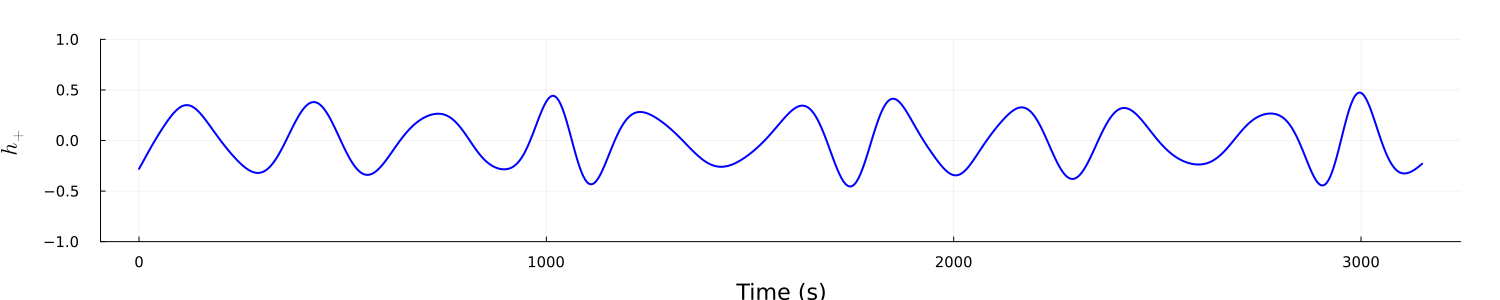

In [24]:
# NOTE: can multiply by "strain_to_SI" to convert waveform to SI units
gr()
p1 = plot(t_wf, h_plus / mass_ratio, 
color=col,
linestyle=ls,
linewidth=lw,
legend =false,
xlabel = "Time (s)",
ylabel = L"h_{+}",
size=(wave_width, wave_height),
left_margin		=  left_margin,
right_margin	=  right_margin,
top_margin		=  top_margin,
bottom_margin	=  bottom_margin,
xtickfontsize = xtickfontsize,
ytickfontsize = ytickfontsize,
guidefontsize = guidefontsize,
ylims = (-1, 1),
dpi=100)

# plot!(p1, t_wf, h_plus, color=col_2, linestyle=ls_2, linewidth=lw_2, label="All Modes")

display("image/png", p1)